## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-May-2nd_filled.csv', encoding=enc)
#wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_2008-2019.csv', encoding=enc)

In [5]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,abano terme,veneto,11.79539,45.35783,2023-05-16,2023,5,2023-05-13,45.358184,11.797125,0.305836,0.195181,-0.211233,-0.195181,0.451248,0.214649,-0.369369,-0.214649,0.138496,0.084394,0.116102,0.084394,2023-05-16,45.358184,11.797125,14793.0,14140.0,45.358184,11.797125,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,2023-05-16,45.350207,11.750054,248.764906,2023-05-09,2023-05-02,2023-05-09,2023-05-02,70.863885,89.657674
1,adria,veneto,12.03247,45.07647,2023-05-16,2023,5,2023-05-13,45.075215,12.030687,0.663630,0.398058,-0.596588,-0.398058,0.186254,0.098625,-0.137048,-0.098625,0.000000,0.000000,0.000000,0.000000,2023-05-16,45.075215,12.030687,14939.0,13861.0,45.075215,12.030687,13924.375000,13752.800000,14071.181818,13559.142857,14506.750000,13868.692308,14745.500000,13934.300000,2023-05-16,45.050206,12.050055,443.337031,2023-05-09,2023-05-02,2023-05-09,2023-05-02,79.000943,86.508775
2,adria,veneto,12.05787,45.05851,2023-05-16,2023,5,2023-05-13,45.057249,12.057637,0.172279,-0.082630,-0.196530,0.082630,0.272312,0.014919,-0.282289,-0.014919,0.098724,0.146178,0.079921,0.146178,2023-05-16,45.057249,12.057637,15072.0,13873.0,45.057249,12.057637,14018.166667,13711.800000,14072.000000,13638.083333,14510.727273,13940.769231,14732.461538,13989.000000,2023-05-16,45.050206,12.050055,443.337031,2023-05-09,2023-05-02,2023-05-09,2023-05-02,79.000943,86.508775
3,adria,veneto,12.05787,45.07647,2023-05-16,2023,5,2023-05-13,45.075215,12.057637,0.607957,0.338719,-0.539605,-0.338719,0.423923,0.196162,-0.413077,-0.196162,0.173547,0.153933,0.124206,0.153933,2023-05-16,45.075215,12.057637,14882.0,13791.0,45.075215,12.057637,13942.000000,13738.333333,14045.700000,13574.000000,14485.454545,13886.923077,14697.000000,13907.700000,2023-05-16,45.050206,12.050055,443.337031,2023-05-09,2023-05-02,2023-05-09,2023-05-02,79.000943,86.508775
4,affi,veneto,10.77673,45.55680,2023-05-16,2023,5,2023-05-13,45.555814,10.777538,0.215253,0.343317,-0.097417,-0.343317,0.286031,0.303942,-0.179514,-0.303942,0.070778,0.039374,0.082097,0.039374,2023-05-16,45.555814,10.777538,14715.0,14218.0,45.555814,10.777538,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,2023-05-16,45.550208,10.750049,102.643676,2023-05-09,2023-05-02,2023-05-09,2023-05-02,32.024413,44.276372


In [6]:
# wnv_file.head()

In [7]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
timeline_file = timeline_file.rename(columns=lambda x: re.sub('_new', '', x))

In [9]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [10]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,abano terme,veneto,11.79539,45.35783,2023-05-16,2023,5,0.305836,0.195181,-0.211233,-0.195181,0.451248,0.214649,-0.369369,-0.214649,0.138496,0.084394,0.116102,0.084394,14793.0,14140.0,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,248.764906,70.863885,89.657674
1,adria,veneto,12.03247,45.07647,2023-05-16,2023,5,0.663630,0.398058,-0.596588,-0.398058,0.186254,0.098625,-0.137048,-0.098625,0.000000,0.000000,0.000000,0.000000,14939.0,13861.0,13924.375000,13752.800000,14071.181818,13559.142857,14506.750000,13868.692308,14745.500000,13934.300000,443.337031,79.000943,86.508775
2,adria,veneto,12.05787,45.05851,2023-05-16,2023,5,0.172279,-0.082630,-0.196530,0.082630,0.272312,0.014919,-0.282289,-0.014919,0.098724,0.146178,0.079921,0.146178,15072.0,13873.0,14018.166667,13711.800000,14072.000000,13638.083333,14510.727273,13940.769231,14732.461538,13989.000000,443.337031,79.000943,86.508775
3,adria,veneto,12.05787,45.07647,2023-05-16,2023,5,0.607957,0.338719,-0.539605,-0.338719,0.423923,0.196162,-0.413077,-0.196162,0.173547,0.153933,0.124206,0.153933,14882.0,13791.0,13942.000000,13738.333333,14045.700000,13574.000000,14485.454545,13886.923077,14697.000000,13907.700000,443.337031,79.000943,86.508775
4,affi,veneto,10.77673,45.55680,2023-05-16,2023,5,0.215253,0.343317,-0.097417,-0.343317,0.286031,0.303942,-0.179514,-0.303942,0.070778,0.039374,0.082097,0.039374,14715.0,14218.0,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,102.643676,32.024413,44.276372


In [11]:
# wnv_file.head(5)

In [12]:
# ## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_timeline:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")


In [13]:
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('barbarano vicentino','barbarano mossano'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('biancade','roncade'))
# wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'brescia')].index , inplace=True)
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('castelnuovo bariano','castelnovo bariano'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('frassinelle','frassinelle polesine'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('giacciano in barucchella','giacciano con baruchella'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('godega saint urbano','godega da saint urbano'))
# wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'localita ca barzoni')].index , inplace=True)
# wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'mantova')].index , inplace=True)
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('marghera','venezia'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('masera','masera da padova'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('mestre','venezia'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('monastier','monastier da treviso'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('monteforte','monteforte da alpone'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('montegrotto','montegrotto terme'))
# wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'palermo')].index , inplace=True)
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('pra maggiore','pramaggiore'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint elena da silea','saint elena'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietri viminario','saint pietro viminario'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietro morubio','saint pietro da morubio'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietro da morubi','saint pietro da morubio'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('selvazzano','selvazzano dentro'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('vialeggio sul mincio','valeggio sul mincio'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('vo euganeo','vo'))


In [14]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_timeline:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [15]:
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietro da morubioo','saint pietro da morubio'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('selvazzano dentro dentro','selvazzano dentro'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('masera da padovada sul piave','masera da padova'))

In [16]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_timeline:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [17]:
#merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )
merged = timeline_file

In [18]:
# merged

In [19]:
# merged = fillna(merged,{'case': 0})
merged['case'] = 0

In [20]:
merged['case'].value_counts()

0    804
Name: case, dtype: int64

In [21]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [22]:
dataset = grouped.mean()

In [23]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2023-05-16,abano terme,veneto,11.795390,45.357830,2023.0,5.0,0.305836,0.195181,-0.211233,-0.195181,0.451248,0.214649,-0.369369,-0.214649,0.138496,0.084394,0.116102,0.084394,14793.000000,14140.000000,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,248.764906,70.863885,89.657674,0.0
1,2023-05-16,adria,veneto,12.049403,45.070483,2023.0,5.0,0.481289,0.218049,-0.444241,-0.218049,0.294163,0.103235,-0.277471,-0.103235,0.090757,0.100037,0.068042,0.100037,14964.333333,13841.666667,13961.513889,13734.311111,14062.960606,13590.408730,14500.977273,13898.794872,14724.987179,13943.666667,443.337031,79.000943,86.508775,0.0
2,2023-05-16,affi,veneto,10.776730,45.556800,2023.0,5.0,0.215253,0.343317,-0.097417,-0.343317,0.286031,0.303942,-0.179514,-0.303942,0.070778,0.039374,0.082097,0.039374,14715.000000,14218.000000,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,102.643676,32.024413,44.276372,0.0
3,2023-05-16,agna,veneto,11.965390,45.175310,2023.0,5.0,0.285199,-0.009342,-0.308480,0.009342,0.363783,0.092128,-0.365535,-0.092128,0.087480,0.080303,0.066134,0.080303,14835.000000,14251.000000,13874.500000,13686.750000,14045.111111,13555.769231,14457.333333,13878.888889,14720.230769,13913.461538,402.548818,82.096243,96.321740,0.0
4,2023-05-16,agordo,veneto,12.059120,46.313990,2023.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2023-05-16,zevio,veneto,11.127335,45.353970,2023.0,5.0,0.557068,0.281638,-0.474726,-0.281638,0.526192,0.279376,-0.447319,-0.279376,0.067586,0.054155,0.060909,0.054155,14804.000000,14281.500000,13976.444444,13611.633929,14099.275000,13581.468750,14606.142857,13901.145455,14722.108333,13993.187500,134.635950,56.221731,64.747591,0.0
567,2023-05-16,zimella,veneto,11.358050,45.347770,2023.0,5.0,0.238728,0.188525,-0.200552,-0.188525,0.329670,0.225247,-0.288365,-0.225247,0.126394,0.078268,0.104741,0.078268,14817.000000,14136.000000,13930.500000,13658.500000,14134.750000,13579.470588,14627.352941,13914.700000,14812.846154,13957.700000,166.673608,55.920659,63.511989,0.0
568,2023-05-16,zoppe da cadore,veneto,12.178780,46.388350,2023.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0
569,2023-05-16,zovencedo,veneto,11.494300,45.437980,2023.0,5.0,0.494438,0.399115,-0.380781,-0.399115,0.494438,0.399115,-0.380781,-0.399115,0.000000,0.000000,0.000000,0.000000,14627.000000,14174.000000,13943.416667,13727.714286,14065.416667,13746.400000,14413.875000,13990.727273,14519.125000,13987.400000,156.308827,48.271029,68.225934,0.0


In [24]:
dataset = dataset.astype({'case': 'int'})

In [25]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [26]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [27]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [28]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [29]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2023-05-16,abano terme,veneto,11.79539,45.35783,2023,5,0.305836,0.195181,-0.211233,-0.195181,0.451248,0.214649,-0.369369,-0.214649,0.138496,0.084394,0.116102,0.084394,14793.000000,14140.000000,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,248.764906,70.863885,89.657674,0,16,20,46.86645,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507
1,2023-05-16,adria,veneto,12.04940,45.07048,2023,5,0.481289,0.218049,-0.444241,-0.218049,0.294163,0.103235,-0.277471,-0.103235,0.090757,0.100037,0.068042,0.100037,14964.333333,13841.666667,13961.513889,13734.311111,14062.960606,13590.408730,14500.977273,13898.794872,14724.987179,13943.666667,443.337031,79.000943,86.508775,0,16,20,46.65336,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507
2,2023-05-16,affi,veneto,10.77673,45.55680,2023,5,0.215253,0.343317,-0.097417,-0.343317,0.286031,0.303942,-0.179514,-0.303942,0.070778,0.039374,0.082097,0.039374,14715.000000,14218.000000,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,102.643676,32.024413,44.276372,0,16,20,46.81410,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507
3,2023-05-16,agna,veneto,11.96539,45.17531,2023,5,0.285199,-0.009342,-0.308480,0.009342,0.363783,0.092128,-0.365535,-0.092128,0.087480,0.080303,0.066134,0.080303,14835.000000,14251.000000,13874.500000,13686.750000,14045.111111,13555.769231,14457.333333,13878.888889,14720.230769,13913.461538,402.548818,82.096243,96.321740,0,16,20,46.73306,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507
4,2023-05-16,agordo,veneto,12.05912,46.31399,2023,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,16,20,47.85821,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2023-05-16,zevio,veneto,11.12733,45.35397,2023,5,0.557068,0.281638,-0.474726,-0.281638,0.526192,0.279376,-0.447319,-0.279376,0.067586,0.054155,0.060909,0.054155,14804.000000,14281.500000,13976.444444,13611.633929,14099.275000,13581.468750,14606.142857,13901.145455,14722.108333,13993.187500,134.635950,56.221731,64.747591,0,16,20,46.69904,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507
567,2023-05-16,zimella,veneto,11.35805,45.34777,2023,5,0.238728,0.188525,-0.200552,-0.188525,0.329670,0.225247,-0.288365,-0.225247,0.126394,0.078268,0.104741,0.078268,14817.000000,14136.000000,13930.500000,13658.500000,14134.750000,13579.470588,14627.352941,13914.700000,14812.846154,13957.700000,166.673608,55.920659,63.511989,0,16,20,46.74854,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507
568,2023-05-16,zoppe da cadore,veneto,12.17878,46.38835,2023,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,16,20,47.96042,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507
569,2023-05-16,zovencedo,veneto,11.49430,45.43798,2023,5,0.494438,0.399115,-0.380781,-0.399115,0.494438,0.399115,-0.380781,-0.399115,0.000000,0.000000,0.000000,0.000000,14627.000000,14174.000000,13943.416667,13727.714286,14065.416667,13746.400000,14413.875000,13990.727273,14519.125000,13987.400000,156.308827,48.271029,68.225934,0,16,20,46.86928,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507


<AxesSubplot:>

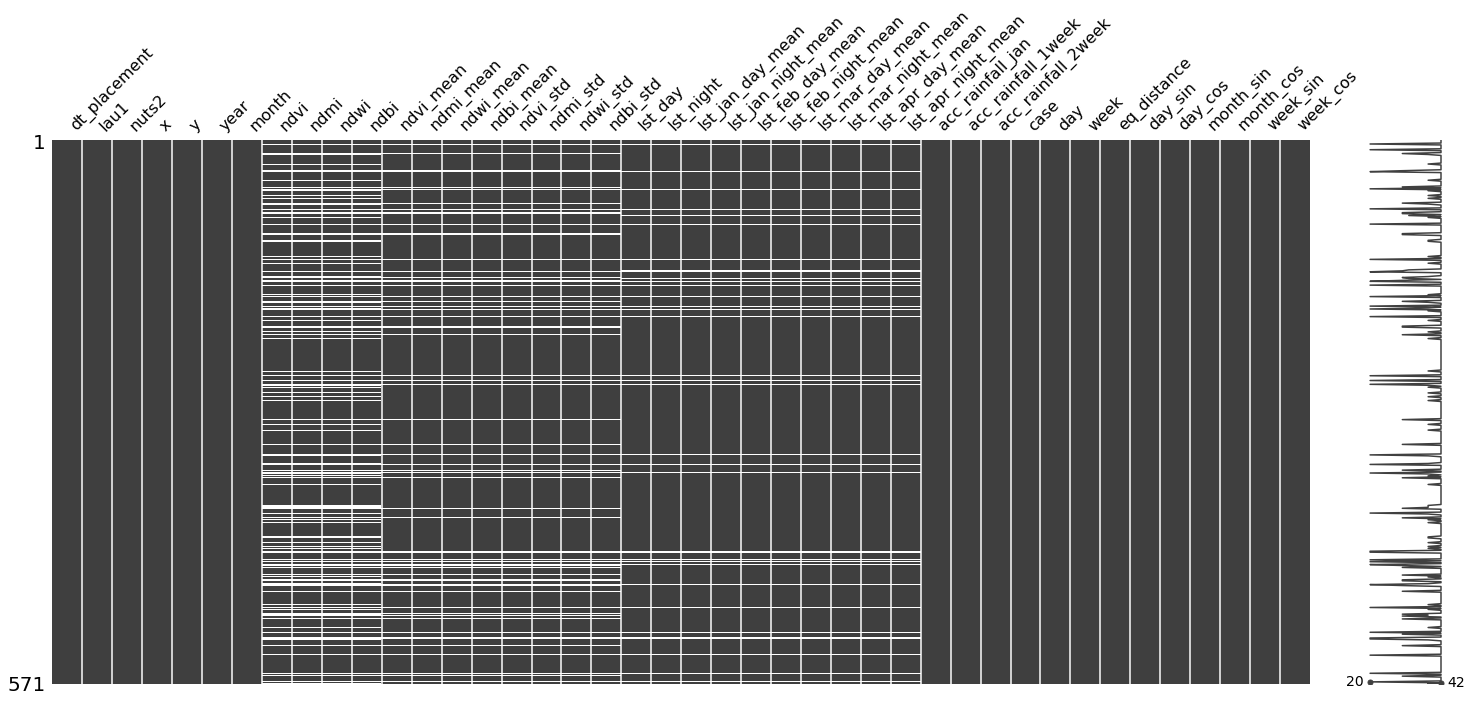

In [30]:
missingno.matrix(dataset)

In [31]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [32]:
df_demographics

,lau1,nuts3,nuts2,population
0,abano terme,padova,veneto,"19,349"
1,adria,rovigo,veneto,"20,233"
2,affi,verona,veneto,"2,297"
3,agna,padova,veneto,"3,400"
4,agordo,belluno,veneto,"4,249"
...,...,...,...,...
576,zimella,verona,veneto,"4,834"
577,zoldo alto,belluno,veneto,999
578,zoppe da cadore,belluno,veneto,265
579,zovencedo,vicenza,veneto,796


In [33]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_LOWER}'").copy()

In [34]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [35]:
df_demographics_nuts2

,lau1,population
0,abano terme,"19,349"
1,adria,"20,233"
2,affi,"2,297"
3,agna,"3,400"
4,agordo,"4,249"
...,...,...
576,zimella,"4,834"
577,zoldo alto,999
578,zoppe da cadore,265
579,zovencedo,796


In [36]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['alpago', 'barbarano mossano', 'borgo veneto', 'brenzone sul garda', 'costermano sul garda', 'quero vas', 'val da zoldo', 'val liona']

Length: 8


In [37]:
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'alpago', 'population':6858}, ignore_index=True)
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('mossano','barbarano mossano'))
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'borgo veneto', 'population':7000}, ignore_index=True)
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'brenzone sul garda', 'population':2452}, ignore_index=True)
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('costermano','costermano sul garda'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('quero','quero vas'))
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'val da zoldo', 'population':3242}, ignore_index=True)
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'val liona', 'population':3047}, ignore_index=True)


In [38]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [39]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

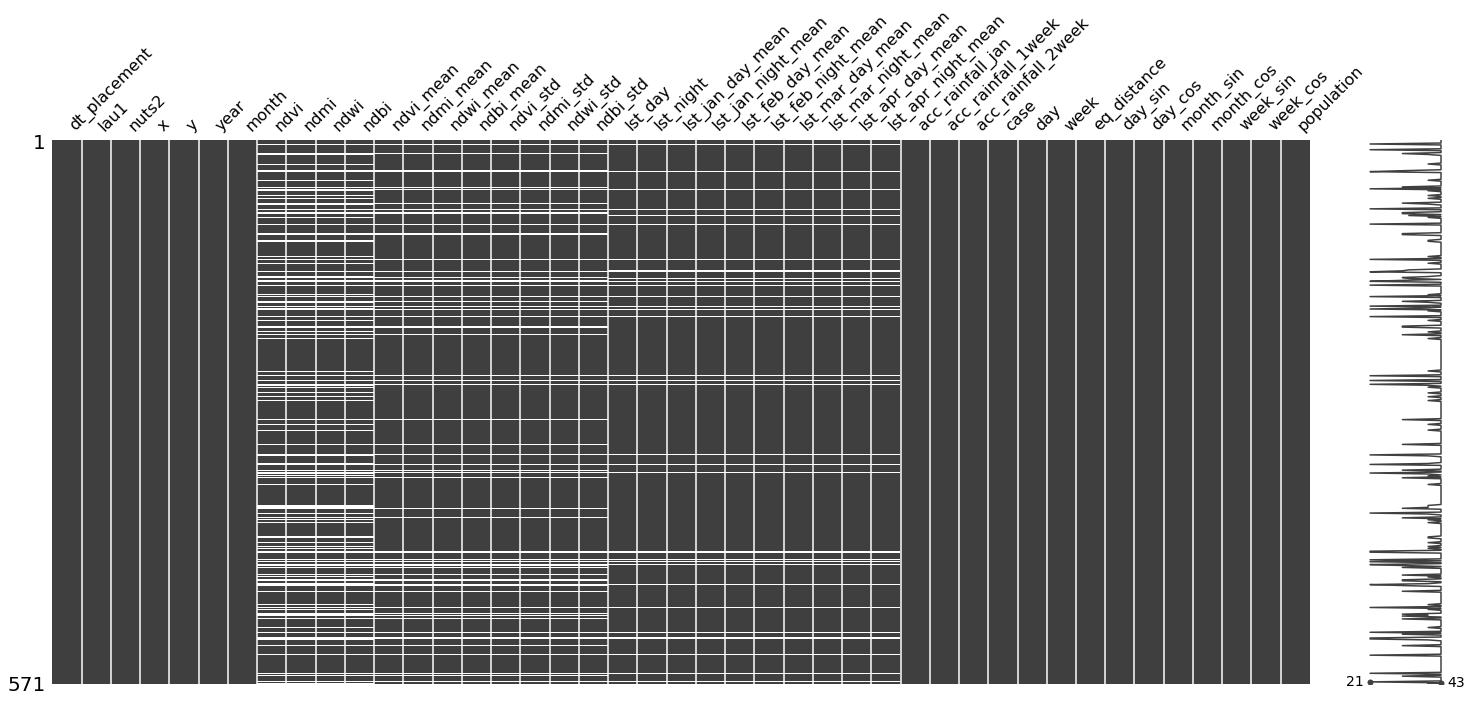

In [40]:
missingno.matrix(dataset)

In [41]:
missing = describe_dataframe(dataset)

In [42]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population
0,2023-05-16,abano terme,veneto,11.79539,45.35783,2023,5,0.305836,0.195181,-0.211233,-0.195181,0.451248,0.214649,-0.369369,-0.214649,0.138496,0.084394,0.116102,0.084394,14793.000000,14140.000000,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,248.764906,70.863885,89.657674,0,16,20,46.86645,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"19,349"
1,2023-05-16,adria,veneto,12.04940,45.07048,2023,5,0.481289,0.218049,-0.444241,-0.218049,0.294163,0.103235,-0.277471,-0.103235,0.090757,0.100037,0.068042,0.100037,14964.333333,13841.666667,13961.513889,13734.311111,14062.960606,13590.408730,14500.977273,13898.794872,14724.987179,13943.666667,443.337031,79.000943,86.508775,0,16,20,46.65336,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"20,233"
2,2023-05-16,affi,veneto,10.77673,45.55680,2023,5,0.215253,0.343317,-0.097417,-0.343317,0.286031,0.303942,-0.179514,-0.303942,0.070778,0.039374,0.082097,0.039374,14715.000000,14218.000000,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,102.643676,32.024413,44.276372,0,16,20,46.81410,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"2,297"
3,2023-05-16,agna,veneto,11.96539,45.17531,2023,5,0.285199,-0.009342,-0.308480,0.009342,0.363783,0.092128,-0.365535,-0.092128,0.087480,0.080303,0.066134,0.080303,14835.000000,14251.000000,13874.500000,13686.750000,14045.111111,13555.769231,14457.333333,13878.888889,14720.230769,13913.461538,402.548818,82.096243,96.321740,0,16,20,46.73306,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"3,400"
4,2023-05-16,agordo,veneto,12.05912,46.31399,2023,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,16,20,47.85821,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"4,249"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2023-05-16,zevio,veneto,11.12733,45.35397,2023,5,0.557068,0.281638,-0.474726,-0.281638,0.526192,0.279376,-0.447319,-0.279376,0.067586,0.054155,0.060909,0.054155,14804.000000,14281.500000,13976.444444,13611.633929,14099.275000,13581.468750,14606.142857,13901.145455,14722.108333,13993.187500,134.635950,56.221731,64.747591,0,16,20,46.69904,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"14,413"
567,2023-05-16,zimella,veneto,11.35805,45.34777,2023,5,0.238728,0.188525,-0.200552,-0.188525,0.329670,0.225247,-0.288365,-0.225247,0.126394,0.078268,0.104741,0.078268,14817.000000,14136.000000,13930.500000,13658.500000,14134.750000,13579.470588,14627.352941,13914.700000,14812.846154,13957.700000,166.673608,55.920659,63.511989,0,16,20,46.74854,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"4,834"
568,2023-05-16,zoppe da cadore,veneto,12.17878,46.38835,2023,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,16,20,47.96042,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,265
569,2023-05-16,zovencedo,veneto,11.49430,45.43798,2023,5,0.494438,0.399115,-0.380781,-0.399115,0.494438,0.399115,-0.380781,-0.399115,0.000000,0.000000,0.000000,0.000000,14627.000000,14174.000000,13943.416667,13727.714286,14065.416667,13746.400000,14413.875000,13990.727273,14519.125000,13987.400000,156.308827,48.271029,68.225934,0,16,20,46.86928,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,796


In [43]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-May-2nd.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,11.795390,45.357830,2023-05-16,131
1,12.049403,45.070483,2023-05-16,203
2,10.776730,45.556800,2023-05-16,58
3,11.965390,45.175310,2023-05-16,90
4,12.059120,46.313990,2023-05-16,37
...,...,...,...,...
566,11.127335,45.353970,2023-05-16,123
567,11.358050,45.347770,2023-05-16,202
568,12.178780,46.388350,2023-05-16,32
569,11.494300,45.437980,2023-05-16,173


In [44]:
df_mosquitoes['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
df_mosquitoes['x'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [45]:
distances, indicies = calculate_nearest_topological(dataset, df_mosquitoes)

In [46]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0011119492665983


In [47]:
df_mosq = pd.DataFrame(columns=df_mosquitoes.columns)

In [48]:
for index in indicies:
    df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])

df_mosq.drop(columns=['x', 'y', 'dt_placement'], inplace = True)
df_mosq.reset_index(drop=True, inplace=True)

In [49]:
dataset = pd.concat([dataset, df_mosq], axis=1, join = 'outer')

In [50]:
dataset.head()

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,mosq_pred
0,2023-05-16,abano terme,veneto,11.79539,45.35783,2023,5,0.305836,0.195181,-0.211233,-0.195181,0.451248,0.214649,-0.369369,-0.214649,0.138496,0.084394,0.116102,0.084394,14793.000000,14140.000000,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,248.764906,70.863885,89.657674,0,16,20,46.86645,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"19,349",131
1,2023-05-16,adria,veneto,12.04940,45.07048,2023,5,0.481289,0.218049,-0.444241,-0.218049,0.294163,0.103235,-0.277471,-0.103235,0.090757,0.100037,0.068042,0.100037,14964.333333,13841.666667,13961.513889,13734.311111,14062.960606,13590.408730,14500.977273,13898.794872,14724.987179,13943.666667,443.337031,79.000943,86.508775,0,16,20,46.65336,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"20,233",203
2,2023-05-16,affi,veneto,10.77673,45.55680,2023,5,0.215253,0.343317,-0.097417,-0.343317,0.286031,0.303942,-0.179514,-0.303942,0.070778,0.039374,0.082097,0.039374,14715.000000,14218.000000,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,102.643676,32.024413,44.276372,0,16,20,46.81410,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"2,297",58
3,2023-05-16,agna,veneto,11.96539,45.17531,2023,5,0.285199,-0.009342,-0.308480,0.009342,0.363783,0.092128,-0.365535,-0.092128,0.087480,0.080303,0.066134,0.080303,14835.000000,14251.000000,13874.500000,13686.750000,14045.111111,13555.769231,14457.333333,13878.888889,14720.230769,13913.461538,402.548818,82.096243,96.321740,0,16,20,46.73306,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"3,400",90
4,2023-05-16,agordo,veneto,12.05912,46.31399,2023,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,16,20,47.85821,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"4,249",37


<AxesSubplot:>

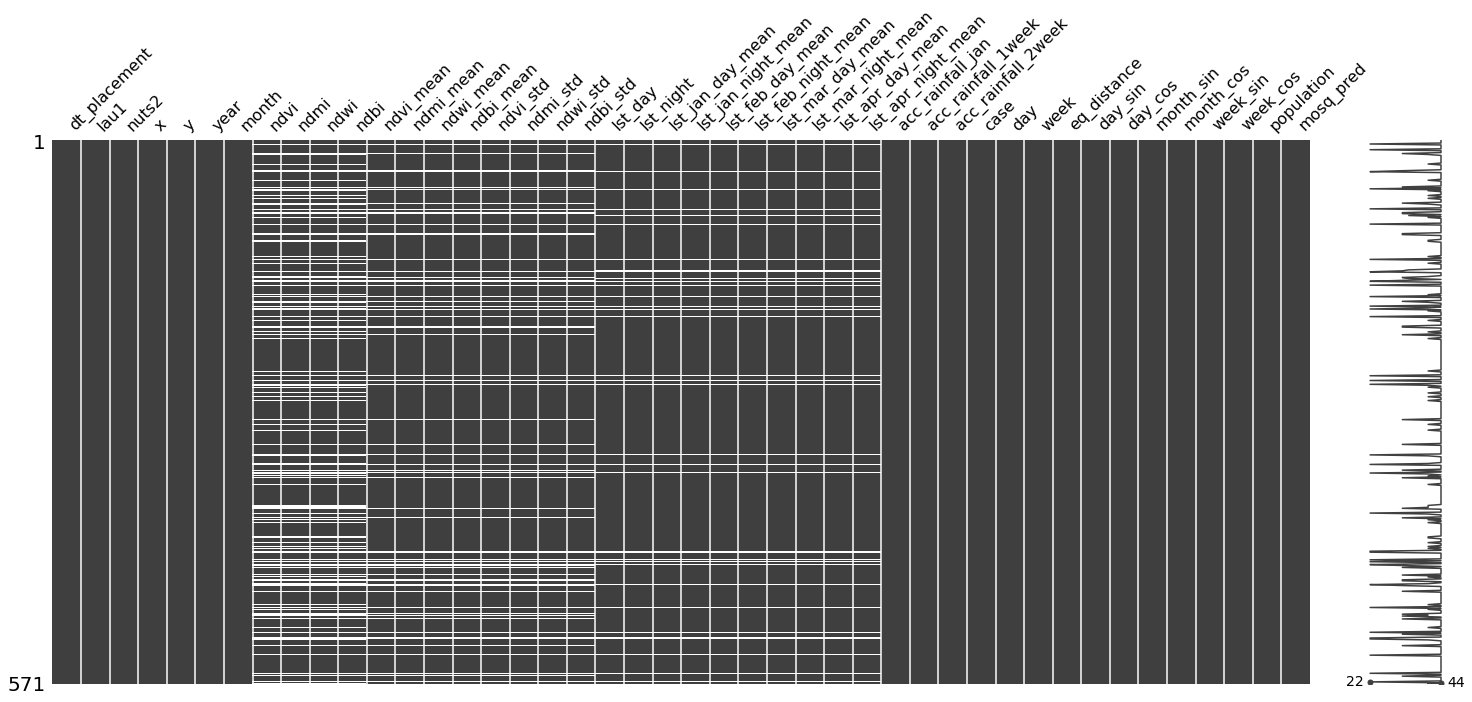

In [51]:
missingno.matrix(dataset)

In [52]:
dataset.reset_index(inplace=True, drop=True)

In [53]:
dataset = calculate_mosq_previous(dataset)

In [54]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

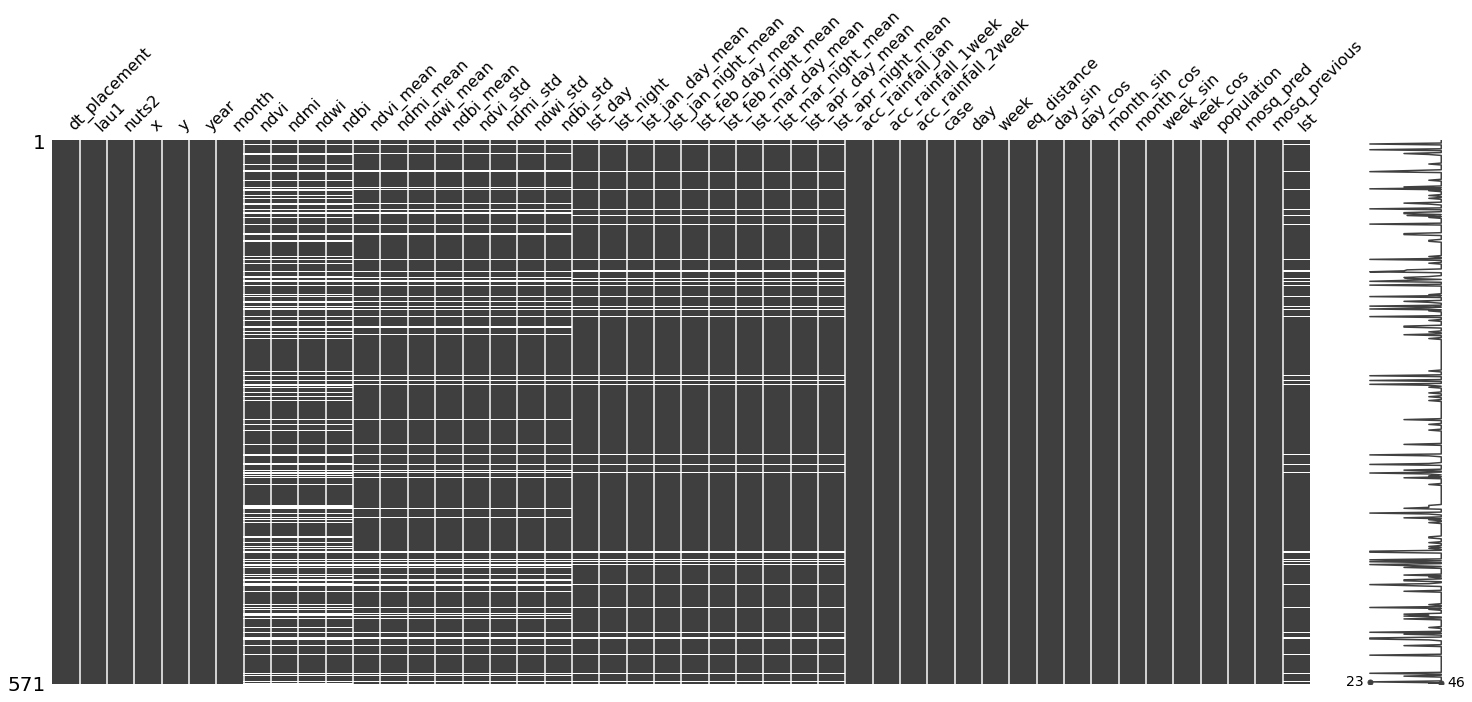

In [55]:
missingno.matrix(dataset)

In [56]:
dataset['case'].value_counts()

0    571
Name: case, dtype: int64

In [57]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [58]:
dataset = convert_multiple_cases(dataset)

In [59]:
dataset['case'].value_counts()

0    571
Name: case, dtype: int64

In [60]:
cols = dataset.columns

In [61]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'population', 'mosq_pred',
       'mosq_previous', 'lst'],
      dtype='object')

In [62]:
len(cols)

46

In [63]:
# check columns

In [64]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'population',
                 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [65]:
len(final_columns)

46

In [66]:
dataset_final = dataset[final_columns].copy()

In [67]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,11.79539,45.35783,2023-05-16,veneto,abano terme,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"19,349",46.86645,0.305836,0.195181,-0.211233,-0.195181,0.451248,0.214649,-0.369369,-0.214649,0.138496,0.084394,0.116102,0.084394,16.180,22.710000,9.650000,7.577500,0.803333,8.080000,-0.791538,18.345385,6.490000,21.500769,6.950000,70.863885,89.657674,248.764906,131,0,0
1,12.04940,45.07048,2023-05-16,veneto,adria,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"20,233",46.65336,0.481289,0.218049,-0.444241,-0.218049,0.294163,0.103235,-0.277471,-0.103235,0.090757,0.100037,0.068042,0.100037,14.910,26.136667,3.683333,6.080278,1.536222,8.109212,-1.341825,16.869545,4.825897,21.349744,5.723333,79.000943,86.508775,443.337031,203,0,0
2,10.77673,45.55680,2023-05-16,veneto,affi,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"2,297",46.81410,0.215253,0.343317,-0.097417,-0.343317,0.286031,0.303942,-0.179514,-0.303942,0.070778,0.039374,0.082097,0.039374,16.180,21.150000,11.210000,6.294444,0.807143,8.631538,0.720667,17.180000,4.251429,18.359412,6.878889,32.024413,44.276372,102.643676,58,0,0
3,11.96539,45.17531,2023-05-16,veneto,agna,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"3,400",46.73306,0.285199,-0.009342,-0.308480,0.009342,0.363783,0.092128,-0.365535,-0.092128,0.087480,0.080303,0.066134,0.080303,17.710,23.550000,11.870000,4.340000,0.585000,7.752222,-2.034615,15.996667,4.427778,21.254615,5.119231,82.096243,96.321740,402.548818,90,0,0
4,12.05912,46.31399,2023-05-16,veneto,agordo,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"4,249",47.85821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,37,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,11.12733,45.35397,2023-05-16,veneto,zevio,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"14,413",46.69904,0.557068,0.281638,-0.474726,-0.281638,0.526192,0.279376,-0.447319,-0.279376,0.067586,0.054155,0.060909,0.054155,17.705,22.930000,12.480000,6.378889,-0.917321,8.835500,-1.520625,18.972857,4.872909,21.292167,6.713750,56.221731,64.747591,134.635950,123,0,0
567,11.35805,45.34777,2023-05-16,veneto,zimella,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"4,834",46.74854,0.238728,0.188525,-0.200552,-0.188525,0.329670,0.225247,-0.288365,-0.225247,0.126394,0.078268,0.104741,0.078268,16.380,23.190000,9.570000,5.460000,0.020000,9.545000,-1.560588,19.397059,5.144000,23.106923,6.004000,55.920659,63.511989,166.673608,202,0,0
568,12.17878,46.38835,2023-05-16,veneto,zoppe da cadore,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,265,47.96042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,32,0,0
569,11.49430,45.43798,2023-05-16,veneto,zovencedo,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,796,46.86928,0.494438,0.399115,-0.380781,-0.399115,0.494438,0.399115,-0.380781,-0.399115,0.000000,0.000000,0.000000,0.000000,14.860,19.390000,10.330000,5.718333,1.404286,8.158333,1.778000,15.127500,6.664545,17.232500,6.598000,48.271029,68.225934,156.308827,173,0,0


In [68]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-May-2nd.csv", encoding = enc, index = False)